In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
rtatman_glove_global_vectors_for_word_representation_path = kagglehub.dataset_download('rtatman/glove-global-vectors-for-word-representation')
praveengovi_emotions_dataset_for_nlp_path = kagglehub.dataset_download('praveengovi/emotions-dataset-for-nlp')
pashupatigupta_emotion_detection_from_text_path = kagglehub.dataset_download('pashupatigupta/emotion-detection-from-text')

print('Data source import complete.')


Using Colab cache for faster access to the 'glove-global-vectors-for-word-representation' dataset.
Using Colab cache for faster access to the 'emotions-dataset-for-nlp' dataset.
Using Colab cache for faster access to the 'emotion-detection-from-text' dataset.
Data source import complete.


# Importing libraries

In [ ]:
import re
import nltk
import string
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, LSTM, Embedding, Bidirectional

nltk.download("stopwords")
nltk.download('wordnet')
stop_words = set(stopwords.words("english"))
lemmatizer= WordNetLemmatizer()

# Modelling
from sklearn.model_selection import train_test_split,KFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score
from sklearn.svm import SVC

#Lime
!pip install lime
from lime import lime_text
from lime.lime_text import LimeTextExplainer
from lime.lime_text import IndexedString,IndexedCharacters
from lime.lime_base import LimeBase
from lime.lime_text import explanation
sns.set(font_scale=1.3)
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [ ]:
# Read datasets
df_train = pd.read_csv('train.txt', names=['Text', 'Emotion'], sep=';')
df_val = pd.read_csv('val.txt', names=['Text', 'Emotion'], sep=';')
df_test = pd.read_csv('test.txt', names=['Text', 'Emotion'], sep=';')

# Remove the header row that was incorrectly read as data
df_train = df_train.iloc[1:].copy()
df_val = df_val.iloc[1:].copy()
df_test = df_test.iloc[1:].copy()

df_train.reset_index(inplace=True, drop=True)
df_val.reset_index(inplace=True, drop=True)
df_test.reset_index(inplace=True, drop=True)

In [ ]:
#print first 5 rows
df_train.head()

,Text,Emotion
0,i think about it i feel violent,6.0
1,i feel so grouchy a class post count link href...,6.0
2,i wonder if anyone is even looking at my mater...,8.0
3,i still don t feel very funny,4.0
4,im still feeling a bit grouchy,6.0


In [ ]:
#print the shape of the data set
print(df_train.shape)

(299440, 2)


In [ ]:
#print first 5 rows
df_test.head()

,Text,Emotion
0,i feel like a petty girl whos wasting her time...,6.0
1,i also feel arisnote is a useful program,8.0
2,i could help but feel deeply doubtful about my...,3.0
3,i was suppose to feel amazing but i didnt and ...,8.0
4,i started to feel horny and responded to her k...,8.0


In [ ]:
#print the shape of the data set
print(df_test.shape)

(63093, 2)


In [ ]:
#print first 5 rows
df_val.head()

,Text,Emotion
0,i was not feeling terrific i did manage to do ...,8.0
1,i feel weird and out of place,3.0
2,i feel he that wonderful young man who drives ...,8.0
3,i havent written a wishlist post since august ...,8.0
4,i cant stay like i am any longer i feel like a...,8.0


In [ ]:
#print the shape of the data set
print(df_val.shape)

(53621, 2)


# Assessing

## Train dataset

In [ ]:
#check if the data is balanced or not
df_train.Emotion.value_counts()

,count
Emotion,
1.0,86295
8.0,73169
7.0,61456
6.0,35194
3.0,30385
4.0,9665
5.0,1896
2.0,1380


In [ ]:
#check if the data is balanced or not
df_train.Emotion.value_counts() / df_train.shape[0] *100

,count
Emotion,
1.0,28.818795
8.0,24.435279
7.0,20.523644
6.0,11.753273
3.0,10.147275
4.0,3.227692
5.0,0.633182
2.0,0.460860


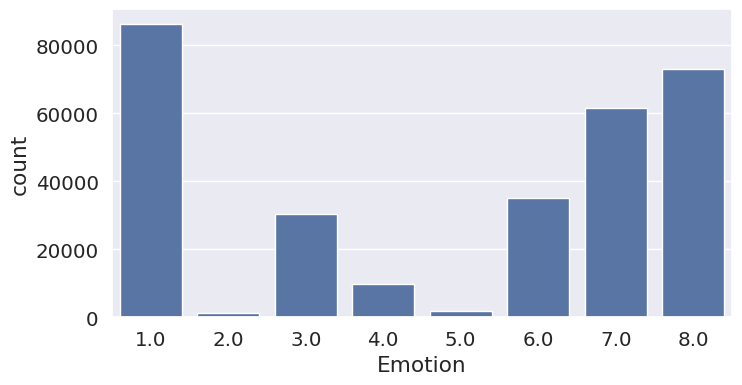

In [ ]:
plt.figure(figsize=(8,4))
sns.countplot(x='Emotion', data=df_train);

The data is imbalanced so, we may try to balance it but also, the emotions that we interested in are the most repeated emotion so, till now we can keep the data as it is

In [ ]:
#print the number of null values in each column
df_train.isnull().sum()

,0
Text,0
Emotion,0


The data doesn't contains any null values

In [ ]:
#print the number of duplicated values
df_train.duplicated().sum()

np.int64(299006)

There is just one row which is duplicated but we need to check also if there are rows having the same text but different emotions

In [ ]:
#removing duplicated values
index = df_train[df_train.duplicated() == True].index
df_train.drop(index, axis = 0, inplace = True)
df_train.reset_index(inplace=True, drop = True)

In [ ]:
#print the rows which are duplicated (duplicated in the text but with different emotions)
df_train[df_train['Text'].duplicated() == True]

,Text,Emotion
429,i pretty much waddled out of the hospital feel...,8.0
430,i feel sickened by and disgusted with the sins...,5.0
431,i feel rather disgusted after seeing his photo...,5.0
432,i have a little extra interest in this right n...,2.0
433,i feel that i have nothing smart or interestin...,2.0


In [ ]:
#print some of those rows to check
df_train[df_train['Text'] == df_train.iloc[0]['Text']]

,Text,Emotion
0,i think about it i feel violent,6.0


In [ ]:
df_train[df_train['Text'] == df_train.iloc[0]['Text']]

,Text,Emotion
0,i think about it i feel violent,6.0


In [ ]:
df_train[df_train['Text'] == df_train.iloc[0]['Text']]

,Text,Emotion
0,i think about it i feel violent,6.0


In [ ]:
#removing duplicated text
index = df_train[df_train['Text'].duplicated() == True].index
df_train.drop(index, axis = 0, inplace = True)
df_train.reset_index(inplace=True, drop = True)

In [ ]:
#Count the number of stopwords in the data
temp =df_train.copy()
stop_words = set(stopwords.words("english"))
temp['stop_words'] = temp['Text'].apply(lambda x: len(set(x.split()) & set(stop_words)))
temp.stop_words.value_counts()

,count
stop_words,
5,43
6,42
7,41
3,38
8,34
4,30
9,30
12,25
2,24


The data contains alot of stopwords (some rows contains more than 25 stopword!) so, we need to take care when we remove them as some rows may become empty

<Axes: ylabel='Frequency'>

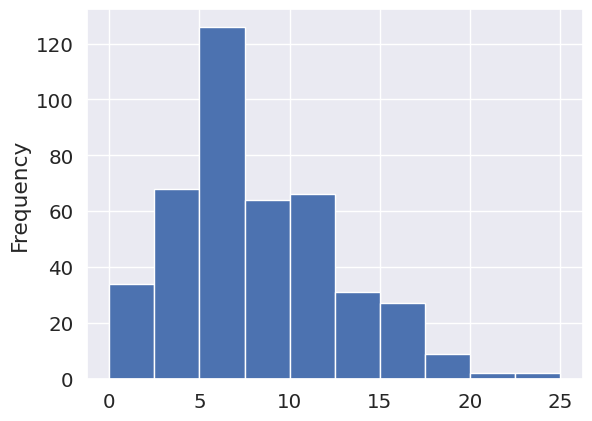

In [ ]:
#distribution of stopwords visually
temp['stop_words'].plot(kind= 'hist')


## Test dataset

In [ ]:
#check if the data is balanced or not
df_test.Emotion.value_counts()

,count
Emotion,
1.0,17427
8.0,14787
7.0,12405
6.0,7121
3.0,6129
4.0,1952
5.0,1894
2.0,1378


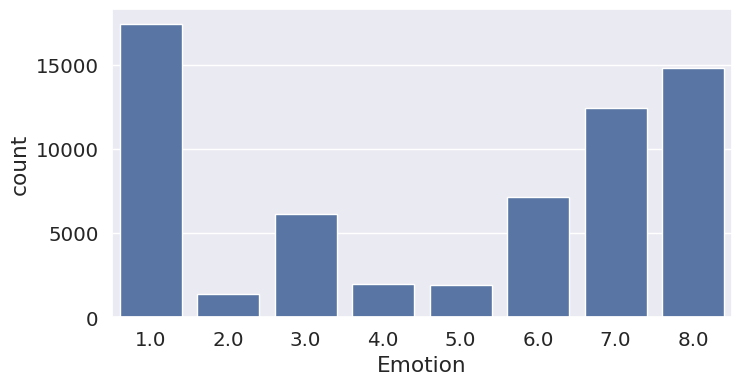

In [ ]:
plt.figure(figsize=(8,4))
sns.countplot(x='Emotion', data=df_test);



In [ ]:
#print the number of null values in each column
df_test.isnull().sum()

,0
Text,0
Emotion,0


In [ ]:
#print the number of duplicated values
df_test.duplicated().sum()

np.int64(62660)

In [ ]:

#print the rows which are duplicated
df_test[df_test['Text'].duplicated() == True]



,Text,Emotion
429,i feel like a petty girl whos wasting her time...,6.0
430,i also feel arisnote is a useful program,8.0
431,i could help but feel deeply doubtful about my...,3.0
432,i was suppose to feel amazing but i didnt and ...,8.0
433,i started to feel horny and responded to her k...,8.0
...,...,...
63088,i feel rather disgusted after seeing his photo...,5.0
63089,i feel sickened by and disgusted with the sins...,5.0
63090,i feel rather disgusted after seeing his photo...,5.0
63091,i feel sickened by and disgusted with the sins...,5.0


In [ ]:
#Count the number of stopwords in the data
temp =df_test.copy()
temp['stop_words'] = temp['Text'].apply(lambda x: len(set(x.split()) & set(stop_words)))
temp.stop_words.value_counts()


,count
stop_words,
7,7348
3,6245
5,5993
6,5855
8,4744
9,4187
4,4183
12,3483
2,3347


<Axes: ylabel='Frequency'>

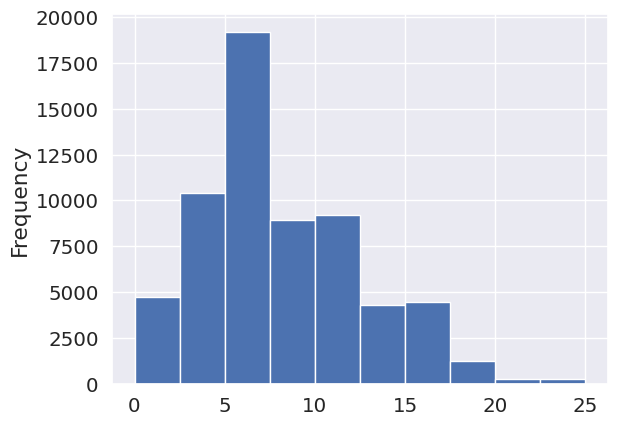

In [ ]:
sns.set(font_scale=1.3)
temp['stop_words'].plot(kind= 'hist')

## Validation dataset

In [ ]:
#check if the data is balanced or not
df_val.Emotion.value_counts()

,count
Emotion,
1.0,14672
8.0,12433
7.0,10453
6.0,5975
3.0,5172
5.0,1894
4.0,1644
2.0,1378


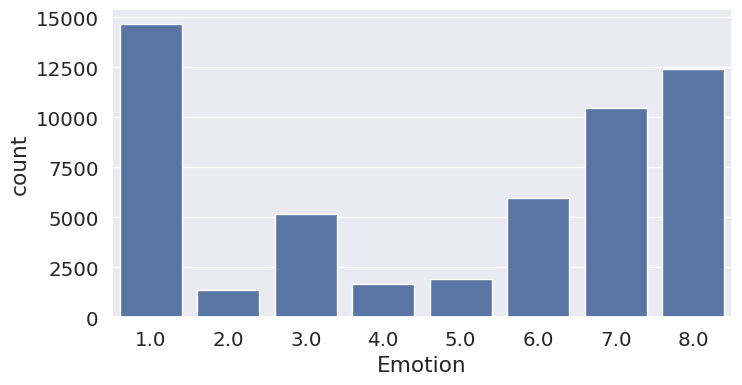

In [ ]:
plt.figure(figsize=(8,4))
sns.countplot(x='Emotion', data=df_val);

In [ ]:
#print the number of null values in each column
df_val.isnull().sum()

,0
Text,0
Emotion,0


In [ ]:
#print the number of duplicated values
df_val.duplicated().sum()

np.int64(53188)

In [ ]:
#print the rows which are duplicated
df_val[df_val['Text'].duplicated() == True]

,Text,Emotion
429,i was not feeling terrific i did manage to do ...,8.0
430,i feel weird and out of place,3.0
431,i feel he that wonderful young man who drives ...,8.0
432,i havent written a wishlist post since august ...,8.0
433,i cant stay like i am any longer i feel like a...,8.0
...,...,...
53616,i feel rather disgusted after seeing his photo...,5.0
53617,i feel sickened by and disgusted with the sins...,5.0
53618,i feel rather disgusted after seeing his photo...,5.0
53619,i feel sickened by and disgusted with the sins...,5.0


In [ ]:
df_val[df_val['Text'] == df_val.iloc[603]['Text']]


,Text,Emotion
174,i don t feel afraid i m a nurse i m doing my job,3.0
603,i don t feel afraid i m a nurse i m doing my job,3.0
1032,i don t feel afraid i m a nurse i m doing my job,3.0
1461,i don t feel afraid i m a nurse i m doing my job,3.0
1890,i don t feel afraid i m a nurse i m doing my job,3.0
...,...,...
48534,i don t feel afraid i m a nurse i m doing my job,3.0
48963,i don t feel afraid i m a nurse i m doing my job,3.0
49392,i don t feel afraid i m a nurse i m doing my job,3.0
49821,i don t feel afraid i m a nurse i m doing my job,3.0


In [ ]:
df_val[df_val['Text'] == df_val.iloc[1993]['Text']]


,Text,Emotion
277,i had much trepidation about forcing the issue...,7.0
706,i had much trepidation about forcing the issue...,7.0
1135,i had much trepidation about forcing the issue...,7.0
1564,i had much trepidation about forcing the issue...,7.0
1993,i had much trepidation about forcing the issue...,7.0
...,...,...
48208,i had much trepidation about forcing the issue...,7.0
48637,i had much trepidation about forcing the issue...,7.0
49066,i had much trepidation about forcing the issue...,7.0
49495,i had much trepidation about forcing the issue...,7.0


In [ ]:
#removing duplicated text
index = df_val[df_val['Text'].duplicated() == True].index
df_val.drop(index, axis = 0, inplace = True)
df_val.reset_index(inplace=True, drop = True)

In [ ]:
#Count the number of stopwords in the data
temp =df_val.copy()
temp['stop_words'] = temp['Text'].apply(lambda x: len(set(x.split()) & set(stop_words)))
temp.stop_words.value_counts()[:10]


,count
stop_words,
5,43
6,42
7,41
3,38
8,34
4,30
9,30
12,25
2,24


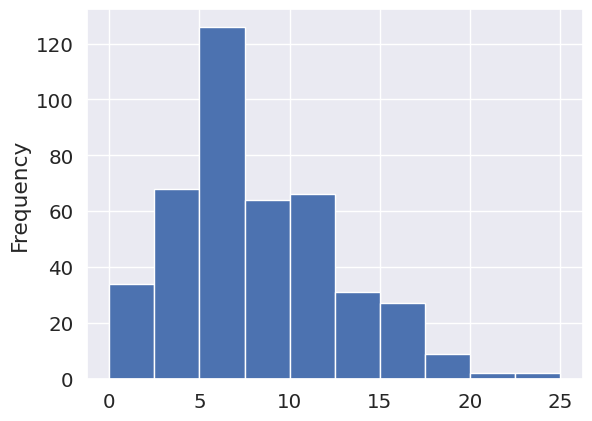

In [ ]:
sns.set(font_scale=1.3)
temp['stop_words'].plot(kind= 'hist');

## Compare rows of the datasets

check that there is no data leakage

In [ ]:
def dataframe_difference(df1, df2, which=None):
    """Find rows which are different between two DataFrames."""

    # Combine the two DataFrames using a merge operation, with the
    # indicator parameter set to True. This adds a column called _merge
    # to the resulting DataFrame, which indicates the source of each row.
    comparison_df = df1.merge(
        df2,
        indicator=True,
        how='outer'
    )

    # Filter the merged DataFrame based on the value of _merge. If which
    # is not specified, return all rows where _merge is not 'both'.
    # Otherwise, return all rows where _merge has the specified value
    if which is None:
        diff_df = comparison_df[comparison_df['_merge'] != 'both']
    else:
        diff_df = comparison_df[comparison_df['_merge'] == which]

    # Return the filtered DataFrame
    return diff_df

In [ ]:
dataframe_difference(df_train, df_test, which='both')

,Text,Emotion,_merge
0,article published,8.0,both
1,article published,8.0,both
2,article published,8.0,both
3,article published,8.0,both
4,article published,8.0,both
...,...,...,...
63088,when my kid brother broke my reading spectacles,6.0,both
63089,when my kid brother broke my reading spectacles,6.0,both
63090,when my kid brother broke my reading spectacles,6.0,both
63091,when my kid brother broke my reading spectacles,6.0,both


In [ ]:
dataframe_difference(df_train, df_val, which='both')

,Text,Emotion,_merge
0,article published,8.0,both
1,football was a very big deal at my high school,7.0,both
2,held under water by a large wave and thought i...,3.0,both
3,i actually think i am a fairly authentic perso...,1.0,both
4,i already feel awful about what happened and i...,1.0,both
...,...,...,...
424,ive postponed writing this post because i feel...,3.0,both
425,ive probably mentioned this before but i reall...,8.0,both
426,ive said i really feel feel as remorseful as e...,1.0,both
427,the event which got me angry got also an avers...,6.0,both


In [ ]:
dataframe_difference(df_val, df_test, which='both')

,Text,Emotion,_merge
0,article published,8.0,both
1,article published,8.0,both
2,article published,8.0,both
3,article published,8.0,both
4,article published,8.0,both
...,...,...,...
63088,when my kid brother broke my reading spectacles,6.0,both
63089,when my kid brother broke my reading spectacles,6.0,both
63090,when my kid brother broke my reading spectacles,6.0,both
63091,when my kid brother broke my reading spectacles,6.0,both


## Cleaning

In [ ]:
def lemmatization(text):
    lemmatizer= WordNetLemmatizer()

    text = text.split()

    text=[lemmatizer.lemmatize(y) for y in text]

    return " " .join(text)

def remove_stop_words(text):

    Text=[i for i in str(text).split() if i not in stop_words]
    return " ".join(Text)

def Removing_numbers(text):
    text=''.join([i for i in text if not i.isdigit()])
    return text

def lower_case(text):

    text = text.split()

    text=[y.lower() for y in text]

    return " " .join(text)

def Removing_punctuations(text):
    ## Remove punctuations
    text = re.sub('[%s]' % re.escape("""!"#$%&'()*+,،-./:;<=>؟?@[\]^_`{|}~"""), ' ', text)
    text = text.replace('؛',"", )

    ## remove extra whitespace
    text = re.sub('\s+', ' ', text)
    text =  " ".join(text.split())
    return text.strip()

def Removing_urls(text):
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    return url_pattern.sub(r'', text)

def remove_small_sentences(df):
    for i in range(len(df)):
        if len(df.text.iloc[i].split()) < 3:
            df.text.iloc[i] = np.nan

def normalize_text(df):
    df.Text=df.Text.apply(lambda text : lower_case(text))
    df.Text=df.Text.apply(lambda text : remove_stop_words(text))
    df.Text=df.Text.apply(lambda text : Removing_numbers(text))
    df.Text=df.Text.apply(lambda text : Removing_punctuations(text))
    df.Text=df.Text.apply(lambda text : Removing_urls(text))
    df.Text=df.Text.apply(lambda text : lemmatization(text))
    return df

def normalized_sentence(sentence):
    sentence= lower_case(sentence)
    sentence= remove_stop_words(sentence)
    sentence= Removing_numbers(sentence)
    sentence= Removing_punctuations(sentence)
    sentence= Removing_urls(sentence)
    sentence= lemmatization(sentence)
    return sentence



<>:29: SyntaxWarning: invalid escape sequence '\]'
<>:33: SyntaxWarning: invalid escape sequence '\s'
<>:29: SyntaxWarning: invalid escape sequence '\]'
<>:33: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_73938/1282799840.py:29: SyntaxWarning: invalid escape sequence '\]'
  text = re.sub('[%s]' % re.escape("""!"#$%&'()*+,،-./:;<=>؟?@[\]^_`{|}~"""), ' ', text)
/tmp/ipykernel_73938/1282799840.py:33: SyntaxWarning: invalid escape sequence '\s'
  text = re.sub('\s+', ' ', text)


In [ ]:
normalized_sentence("My Name is Mohamed. @Tweets,  plays 2022  Egypt_")


'name mohamed tweet play egypt'

In [ ]:
df_train= normalize_text(df_train)
df_test= normalize_text(df_test)
df_val= normalize_text(df_val)

## Modeling

### TF-IDF
The word counts suffer some issues: most frequent words are usually not important (like stop words), while they take high focus/count.

TFIDF (Term Frequency - Inverse Document) is a way to adjust those counts:

TF: #mentions within a document

IDF: #mentions across all docs

So it gives higher importance to rare words across all docs (IDF++, TFIDF--), while it emphasyses on words appearing mostly in THIS doc (TF++, TFIDF--).

If a word appearing only in the current doc/sentence, it has TFIDF=1. If a word appears in all docs/sents but not the current one, it has TFIDF=0. If a word (stop word for example) appearing a lot in the current doc/sent and also in ALL others, it will have high TF (count) and much higher IDF (discount), so low TFIDF overall.

We will start by baseline models

**Creating a pipline using tf-idf for words embedding and different models.**


In [ ]:
#Preprocess text
X_train = df_train['Text'].values
y_train = df_train['Emotion'].values

X_test = df_test['Text'].values
y_test = df_test['Emotion'].values

X_val = df_val['Text'].values
y_val = df_val['Emotion'].values

In [ ]:
def train_model(model, data, targets):
    """
    Train a model on the given data and targets.

    Parameters:
    model (sklearn model): The model to be trained.
    data (list of str): The input data.
    targets (list of str): The targets.

    Returns:
    Pipeline: The trained model as a Pipeline object.
    """
    # Create a Pipeline object with a TfidfVectorizer and the given model
    text_clf = Pipeline([('vect',TfidfVectorizer()),
                         ('clf', model)])
    # Fit the model on the data and targets
    text_clf.fit(data, targets)
    return text_clf

In [ ]:
def get_F1(trained_model,X,y):
    """
    Get the F1 score for the given model on the given data and targets.

    Parameters:
    trained_model (sklearn model): The trained model.
    X (list of str): The input data.
    y (list of str): The targets.

    Returns:
    array: The F1 score for each class.
    """
    # Make predictions on the input data using the trained model
    predicted=trained_model.predict(X)
    # Calculate the F1 score for the predictions
    f1=f1_score(y,predicted, average=None)
    # Return the F1 score
    return f1

In [ ]:
def train_model(model, data, targets):
    """
    Train a model on the given data and targets.

    Parameters:
    model (sklearn model): The model to be trained.
    data (list of str): The input data.
    targets (list of str): The targets.

    Returns:
    Pipeline: The trained model as a Pipeline object.
    """
    # Create a Pipeline object with a TfidfVectorizer and the given model
    text_clf = Pipeline([('vect',TfidfVectorizer()),
                         ('clf', model)])
    # Fit the model on the data and targets
    text_clf.fit(data, targets)
    return text_clf

In [ ]:
def get_F1(trained_model,X,y):
    """
    Get the F1 score for the given model on the given data and targets.

    Parameters:
    trained_model (sklearn model): The trained model.
    X (list of str): The input data.
    y (list of str): The targets.

    Returns:
    array: The F1 score for each class.
    """
    # Make predictions on the input data using the trained model
    predicted=trained_model.predict(X)
    # Calculate the F1 score for the predictions
    f1=f1_score(y,predicted, average=None)
    # Return the F1 score
    return f1

**Training the Logistic Regression model on the Training set**


In [ ]:
#Train the model with the training data
log_reg = train_model(LogisticRegression(solver='liblinear', random_state = 0, class_weight=class_weights_dict_sklearn), X_train, y_train)

In [ ]:
#Make a single prediction
y_pred=log_reg.predict(['Happy'])
y_pred

array([8.])

In [ ]:
#test the model with the test data
y_pred=log_reg.predict(X_test)

#calculate the accuracy
log_reg_accuracy = accuracy_score(y_test, y_pred)
print('Accuracy: ', log_reg_accuracy,'\n')

#calculate the F1 score
f1_Score = get_F1(log_reg,X_test,y_test)
pd.DataFrame(f1_Score, index=np.sort(df_test.Emotion.unique()), columns=['F1 score'])

Accuracy:  0.7691186026976051 



,F1 score
1.0,0.801260
2.0,0.000000
3.0,0.456366
4.0,0.000000
5.0,0.000000
6.0,0.436118
7.0,0.940152
8.0,0.910109


In [ ]:
##Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         1.0       0.67      1.00      0.80     17427
         2.0       0.00      0.00      0.00      1378
         3.0       1.00      0.30      0.46      6129
         4.0       0.00      0.00      0.00      1952
         5.0       0.00      0.00      0.00      1894
         6.0       0.57      0.35      0.44      7121
         7.0       0.92      0.97      0.94     12405
         8.0       0.84      1.00      0.91     14787

    accuracy                           0.77     63093
   macro avg       0.50      0.45      0.44     63093
weighted avg       0.72      0.77      0.71     63093



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Addressing UndefinedMetricWarning with Class Weights

The `UndefinedMetricWarning` indicates that for some classes (e.g., 2.0 and 5.0 in the classification reports), precision and F1-score are ill-defined. This usually happens when the model makes no predictions for a particular class, or there are no actual instances of that class in the test set. In our case, the `support` column shows that there are indeed samples for these classes, meaning the models are simply failing to predict them.

To address this class imbalance and improve the model's ability to predict minority classes, we can use **class weights**. Class weights are applied during the training process to penalize misclassifications of minority classes more heavily than misclassifications of majority classes. This encourages the model to pay more attention to the underrepresented classes, leading to better overall performance and potentially resolving the `UndefinedMetricWarning`.

We will calculate 'balanced' class weights, which automatically adjust weights inversely proportional to class frequencies in the input data. Higher weights will be assigned to classes with fewer samples.

In [ ]:
from sklearn.utils import class_weight

# Calculate class weights for the sklearn models using original emotion labels from df_train
# This ensures that all classes present in the training data are considered.
classes_sklearn = np.unique(df_train['Emotion'].values)
class_weights_array_sklearn = class_weight.compute_class_weight('balanced', classes=classes_sklearn, y=df_train['Emotion'].values)
class_weights_dict_sklearn = dict(zip(classes_sklearn, class_weights_array_sklearn))

print("Computed class weights for Sklearn models:")
print(class_weights_dict_sklearn)

Computed class weights for Sklearn models:
{np.float64(1.0): np.float64(0.572), np.float64(3.0): np.float64(1.625), np.float64(4.0): np.float64(5.107142857142857), np.float64(6.0): np.float64(1.4019607843137254), np.float64(7.0): np.float64(0.8033707865168539), np.float64(8.0): np.float64(0.6745283018867925)}


**Training the Decision Tree model on the Training set**

In [ ]:
#Train the model with the training data
DT = train_model(DecisionTreeClassifier(random_state = 0, class_weight=class_weights_dict_sklearn), X_train, y_train)

#test the model with the test data
y_pred=DT.predict(X_test)

#calculate the accuracy
DT_accuracy = accuracy_score(y_test, y_pred)
print('Accuracy: ', DT_accuracy,'\n')

#calculate the F1 score
f1_Score = get_F1(DT,X_test,y_test)
pd.DataFrame(f1_Score, index=np.sort(df_test.Emotion.unique()), columns=['F1 score'])

Accuracy:  0.9481400472318641 



,F1 score
1.0,1.000000
2.0,0.000000
3.0,1.000000
4.0,1.000000
5.0,0.000000
6.0,0.882623
7.0,0.972979
8.0,0.977233


In [ ]:
##Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         1.0       1.00      1.00      1.00     17427
         2.0       0.00      0.00      0.00      1378
         3.0       1.00      1.00      1.00      6129
         4.0       1.00      1.00      1.00      1952
         5.0       0.00      0.00      0.00      1894
         6.0       0.79      1.00      0.88      7121
         7.0       0.95      1.00      0.97     12405
         8.0       0.96      1.00      0.98     14787

    accuracy                           0.95     63093
   macro avg       0.71      0.75      0.73     63093
weighted avg       0.90      0.95      0.92     63093



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


** **bold text**Training the Support Vector Machine model on the Training set**


In [ ]:
#Train the model with the training data
SVM = train_model(SVC(random_state = 0, class_weight=class_weights_dict_sklearn), X_train, y_train)

#test the model with the test data
y_pred=SVM.predict(X_test)

#calculate the accuracy
SVM_accuracy = accuracy_score(y_test, y_pred)
print('Accuracy: ', SVM_accuracy,'\n')

#calculate the F1 score
f1_Score = get_F1(SVM,X_test,y_test)
pd.DataFrame(f1_Score, index=np.sort(df_test.Emotion.unique()), columns=['F1 score'])

Accuracy:  0.9481400472318641 



,F1 score
1.0,1.000000
2.0,0.000000
3.0,1.000000
4.0,1.000000
5.0,0.000000
6.0,0.882623
7.0,0.972979
8.0,0.977233


In [ ]:
##Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         1.0       0.96      1.00      0.98     17427
         2.0       0.00      0.00      0.00      1378
         3.0       1.00      1.00      1.00      6129
         4.0       1.00      0.64      0.78      1952
         5.0       0.00      0.00      0.00      1894
         6.0       0.79      1.00      0.88      7121
         7.0       0.95      1.00      0.97     12405
         8.0       0.96      1.00      0.98     14787

    accuracy                           0.94     63093
   macro avg       0.71      0.71      0.70     63093
weighted avg       0.89      0.94      0.91     63093



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Training the Random Forest model on the Training set**

In [ ]:
import numpy as np
#Train the model with the training data
RF = train_model(RandomForestClassifier(random_state = 0, class_weight=class_weights_dict_sklearn), X_train, y_train)

#test the model with the test data
y_pred=RF.predict(X_test)

#calculate the accuracy
RF_accuracy = accuracy_score(y_test, y_pred)
print('Accuracy: ', RF_accuracy,'\n')

#calculate the F1 score
f1_Score = get_F1(RF, X_test, y_test)
pd.DataFrame(f1_Score, index=np.sort(df_test.Emotion.unique()), columns=['F1 score'])

Accuracy:  0.9481400472318641 



,F1 score
1.0,1.000000
2.0,0.000000
3.0,1.000000
4.0,1.000000
5.0,0.000000
6.0,0.882623
7.0,0.972979
8.0,0.977233


In [ ]:
##Classification Report
print(classification_report(y_test, y_pred))

## Results

In [ ]:
models = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree','Support Vector Machine','Random Forest'],
    'Accuracy': [log_reg_accuracy.round(2), DT_accuracy.round(2), SVM_accuracy.round(2), RF_accuracy.round(2)]})

models.sort_values(by='Accuracy', ascending=False).reset_index().drop(['index'], axis=1)

# Lime

LIME, the acronym for local interpretable model-agnostic explanations, is a technique that approximates any black box machine learning model with a local, interpretable model to explain each individual prediction

we need which words contributed the most in the predicition

In [ ]:
#c_LR = make_pipeline(tfidf, clf)
explainer_LR = LimeTextExplainer(class_names=RF.classes_)
idx  = 15
print("Actual Text : ", X_test[idx])
print("Prediction : ", RF.predict(X_test)[idx])
print("Actual :     ", y_test[idx])
exp = explainer_LR.explain_instance(X_test[idx], RF.predict_proba,top_labels=5)
exp.show_in_notebook()

# Better way?
Word embedding using this glove and use a sequance model

## Text Preprocessing

In [ ]:
#Splitting the text from the labels
X_train = df_train['Text']
y_train = df_train['Emotion']

X_test = df_test['Text']
y_test = df_test['Emotion']

X_val = df_val['Text']
y_val = df_val['Emotion']

In [ ]:
# Encode labels
le = LabelEncoder()

# Re-assign y_train, y_test, y_val from their respective DataFrames to ensure they are fresh and untransformed
y_train_original = df_train['Emotion']
y_test_original = df_test['Emotion']
y_val_original = df_val['Emotion']

# Fit the LabelEncoder on all unique emotion labels across all datasets, converting to int first
all_emotions = pd.concat([y_train_original.astype(int), y_test_original.astype(int), y_val_original.astype(int)]).unique()
le.fit(all_emotions)

# Transform the labels
y_train = le.transform(y_train_original.astype(int))
y_test = le.transform(y_test_original.astype(int))
y_val = le.transform(y_val_original.astype(int))

In [ ]:
#print the labels after encoding
print(set(y_train))

In [ ]:
#Convert the class vector (integers) to binary class matrix
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)
y_val = to_categorical(y_val)

In [ ]:
print(y_train)

## Tokenizing

In [ ]:
# Tokenize words
tokenizer = Tokenizer(oov_token='UNK')
tokenizer.fit_on_texts(pd.concat([X_train, X_test], axis=0))

In [ ]:
#word index: A dictionary of words and their uniquely assigned integers.
#tokenizer.word_index

In [ ]:
#word counts: A dictionary of words and their counts.
#tokenizer.word_counts

In [ ]:
#document count: A dictionary of words and how many documents each appeared in.
#in this dataset the output will be the number of rows
tokenizer.document_count

In [ ]:
#word docs: An integer count of the total number of documents(or rows) that were used to fit the Tokenizer.
#tokenizer.word_docs

In [ ]:
#print the index of a single word
tokenizer.word_index['towards']

In [ ]:
#converting a single sentence to list of indexes
tokenizer.texts_to_sequences(X_train[0].split())

In [ ]:
#convert the list of indexes into a matrix of ones and zeros (BOW)
tokenizer.texts_to_matrix(X_train[0].split())

In [ ]:
#the sentence contains three words and the size of the vocabulary is 14325
tokenizer.texts_to_matrix(X_train[0].split()).shape

In [ ]:
sequences_train = tokenizer.texts_to_sequences(X_train)
sequences_test = tokenizer.texts_to_sequences(X_test)
sequences_val = tokenizer.texts_to_sequences(X_val)

In [ ]:
#print the sentence after converting them to indexes
#sequences_train

## Padding

The vectors we obtain are generally not of equal lengths

For that, we might need to pad the sequences to max len.

In [ ]:
df_test.shape

In [ ]:
maxlen = max([len(t) for t in df_train['Text']])
maxlen

In [ ]:
X_train = pad_sequences(sequences_train, maxlen=229, truncating='pre')
X_test = pad_sequences(sequences_test, maxlen=229, truncating='pre')
X_val = pad_sequences(sequences_val, maxlen=229, truncating='pre')

vocabSize = len(tokenizer.index_word) + 1
print(f"Vocabulary size = {vocabSize}")

In [ ]:
#before
sequences_train[0]

In [ ]:
#after
X_train[0]

## Word Embedding

**This code defines the following variables:**

**path_to_glove_file**: The file path to the GloVe word vectors file.

**num_tokens**: The size of the vocabulary. This is typically the number of unique words in the dataset.

**embedding_dim**: The dimensionality of the word vectors. This is usually set to a fixed value (e.g., 200, 300, etc.) depending on the size of the word vectors file that is being used.

**hits**: A counter for the number of words that are found in the embeddings_index dictionary.

**misses**: A counter for the number of words that are not found in the embeddings_index dictionary.

**embeddings_index**: A dictionary that will store the word vectors, with the words as keys and the word vectors as values.

In [ ]:
# Read GloVE embeddings

path_to_glove_file = '../input/glove-global-vectors-for-word-representation/glove.6B.200d.txt'
num_tokens = vocabSize
embedding_dim = 200 #latent factors or features
hits = 0
misses = 0
embeddings_index = {}

I will intialize an embedding matrix with all zero values and then looping through the vocabulary (as defined by the tokenizer object) to assign word vectors to the corresponding rows of the embedding matrix. The word_index attribute of the tokenizer object is a dictionary that maps words to their indices in the vocabulary.

The embedding matrix will have a size of num_tokens rows and embedding_dim columns, where num_tokens is the size of the vocabulary and embedding_dim is the dimensionality of the word vectors.

For each word in the vocabulary, the code looks up the corresponding word vector in the embeddings_index dictionary and assigns it to the corresponding row of the embedding matrix. If the word is not found in the embeddings_index dictionary (i.e., if embedding_vector is None), the code increments the misses counter and the row of the embedding matrix remains all-zeros. If the word is found in the embeddings_index dictionary, the code increments the hits counter and assigns the word vector to the corresponding row of the embedding matrix. Finally, the code prints out the number of words that were converted (hits) and the number that were not found in the embeddings_index dictionary (misses).

In [ ]:
import os

# Read GloVE embeddings
path_to_glove_file = os.path.join(rtatman_glove_global_vectors_for_word_representation_path, 'glove.6B.200d.txt')

with open(path_to_glove_file) as f:
    for line in f:
        word, coefs = line.split(maxsplit=1)
        coefs = np.fromstring(coefs, "f", sep=" ")
        embeddings_index[word] = coefs
print("Found %s word vectors." % len(embeddings_index))

# Assign word vectors to our dictionary/vocabulary
embedding_matrix = np.zeros((num_tokens, embedding_dim))
for word, i in tokenizer.word_index.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        # Words not found in embedding index will be all-zeros.
        # This includes the representation for "padding" and "OOV"
        embedding_matrix[i] = embedding_vector
        hits += 1
    else:
        misses += 1
print("Converted %d words (%d misses)" % (hits, misses))

## Modeling

**The model consists of several layers:**

1. An Embedding layer that takes in integer-encoded text and looks up the embedding vector for each word in the input. The input length is set to the length of the input sequences, and the weights are initialized with an embedding matrix that has been pre-trained on a large dataset. The embedding layer is not trainable, meaning that the weights of this layer will not be updated during training.

2. Three Bidirectional layers, each of which applies a forward and backward LSTM to the input. LSTMs are a type of recurrent neural network that are able to capture long-term dependencies in sequential data. The dropout and recurrent dropout arguments specify the dropout rate to apply to the inputs and recurrent inputs of the LSTMs, respectively. The return_sequences argument specifies whether the LSTM should return the full sequences of outputs or just the last output of each sequence.

3. A Dense layer that applies a linear transformation to the input to produce the output. The output has 6 units and uses the 'softmax' activation function, which means that it will output a probability distribution over the 6 classes.

In [ ]:
# Build neural network architecture

adam = Adam(learning_rate=0.005)

model = Sequential()
model.add(Embedding(vocabSize, 200, input_length=X_train.shape[1], weights=[embedding_matrix], trainable=False))
model.add(Bidirectional(LSTM(256, dropout=0.2,recurrent_dropout=0.2, return_sequences=True)))
model.add(Bidirectional(LSTM(128, dropout=0.2,recurrent_dropout=0.2, return_sequences=True)))
model.add(Bidirectional(LSTM(128, dropout=0.2,recurrent_dropout=0.2)))
model.add(Dense(len(all_emotions), activation='softmax')) # Changed 6 to len(all_emotions)

model.compile(loss='categorical_crossentropy', optimizer=adam, metrics=['accuracy'])
model.summary()

In [ ]:
def create_model(vocab_size, embedding_dim, input_length, embedding_matrix, num_classes, learning_rate=0.005):
    adam = Adam(learning_rate=learning_rate)
    model = Sequential()
    # Removed 'input_length=input_length' as it is deprecated
    model.add(Embedding(vocab_size, embedding_dim, weights=[embedding_matrix], trainable=False))
    model.add(Bidirectional(LSTM(256, dropout=0.2, recurrent_dropout=0.2, return_sequences=True)))
    model.add(Bidirectional(LSTM(128, dropout=0.2, recurrent_dropout=0.2, return_sequences=True)))
    model.add(Bidirectional(LSTM(128, dropout=0.2, recurrent_dropout=0.2)))
    model.add(Dense(num_classes, activation='softmax'))
    model.compile(loss='categorical_crossentropy', optimizer=adam, metrics=['accuracy'])
    return model

**This is the summary of a deep learning model built using the Keras functional API. The model consists of several layers, each of which has a specific type and number of parameters.**

1. The first layer is an "Embedding" layer, which takes in integer-encoded text and looks up the embedding vector for each word in the input. The output of this layer is a 3D tensor with shape (batch_size, sequence_length, embedding_dim), where batch_size is the number of examples in the batch, sequence_length is the length of the input sequences, and embedding_dim is the size of the embedding vectors. In this case, the input sequences are 229 words long and the embedding vectors are 200 dimensions. The embedding layer has a total of 2,863,600 trainable parameters.

2. The next three layers are "Bidirectional" layers, which apply a forward and backward LSTM to the input. LSTMs are a type of recurrent neural network that are able to capture long-term dependencies in sequential data. The output of each bidirectional layer is a 3D tensor with shape (batch_size, sequence_length, units), where units is the number of LSTM units in the layer. In this case, the first bidirectional layer has 512 units, the second has 256 units, and the third has 256 units. Each of these layers has a large number of trainable parameters, as LSTMs are complex models with many internal weights.

3. The final layer is a "Dense" layer, which applies a linear transformation to the input to produce the output. In this case, the output has shape (batch_size, 6), indicating that there are 6 classes. The dense layer has a total of 1,542 trainable parameters.

Overall, the model has a total of 4,851,702 trainable parameters and 2,863,600 non-trainable parameters.

In [ ]:
from tensorflow.keras.utils import plot_model

# Explicitly build the model before plotting
# The input shape should be (sequence_length,) for a single sample
# X_train.shape[1] gives the sequence length (229 in this case)
model.build(input_shape=(None, X_train.shape[1])) # (None, 229) for batch_size, sequence_length

plot_model(model, show_shapes=True)

In [ ]:
#to stop the training when the loss starts to increase
callback = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
)

### K-Fold Cross-Validation for Neural Network

I'll now perform 3-fold cross-validation on the neural network model. This involves combining the training and validation datasets for a more comprehensive evaluation.

In [ ]:
from sklearn.model_selection import KFold
import numpy as np

# Combine training and validation data for K-Fold cross-validation
X_combined = np.concatenate((X_train, X_val))
y_combined = np.concatenate((y_train, y_val))

# Define the number of folds and epochs per fold
n_splits = 3
n_epochs_per_fold = 10 # As requested by the user

kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

fold_accuracies = []
fold_losses = []
all_fold_histories = [] # List to store history objects for each fold

for fold, (train_index, val_index) in enumerate(kf.split(X_combined, y_combined)):
    print(f"\n--- Fold {fold+1}/{n_splits} ---")
    X_fold_train, X_fold_val = X_combined[train_index], X_combined[val_index]
    y_fold_train, y_fold_val = y_combined[train_index], y_combined[val_index]

    # Create a fresh model for each fold
    fold_model = create_model(
        vocab_size=vocabSize,
        embedding_dim=embedding_dim,
        input_length=X_train.shape[1], # Maxlen for padding
        embedding_matrix=embedding_matrix,
        num_classes=len(all_emotions) # Number of unique emotion classes
    )

    # Train the model for this fold
    history_fold = fold_model.fit(
        X_fold_train,
        y_fold_train,
        validation_data=(X_fold_val, y_fold_val),
        epochs=n_epochs_per_fold,
        batch_size=256,
        verbose=1,
        callbacks=[callback] # Using the early stopping callback defined earlier
    )
    all_fold_histories.append(history_fold.history) # Store the history for this fold

    # Evaluate the model on the validation set for this fold
    loss, accuracy = fold_model.evaluate(X_fold_val, y_fold_val, verbose=0)
    print(f"Fold {fold+1} - Validation Loss: {loss:.4f}, Validation Accuracy: {accuracy:.4f}")
    fold_losses.append(loss)
    fold_accuracies.append(accuracy)

print("\n--- Cross-Validation Results ---")
print(f"Average Validation Loss: {np.mean(fold_losses):.4f}")
print(f"Average Validation Accuracy: {np.mean(fold_accuracies):.4f}")

In [ ]:
import matplotlib.pyplot as plt

# Assuming n_epochs_per_fold and n_splits are available from the previous cell

# Initialize lists to store aggregated metrics per epoch across all folds
epoch_train_loss = [[] for _ in range(n_epochs_per_fold)]
epoch_val_loss = [[] for _ in range(n_epochs_per_fold)]
epoch_train_accuracy = [[] for _ in range(n_epochs_per_fold)]
epoch_val_accuracy = [[] for _ in range(n_epochs_per_fold)]

for history in all_fold_histories:
    for i in range(n_epochs_per_fold):
        if i < len(history['loss']):
            epoch_train_loss[i].append(history['loss'][i])
            epoch_val_loss[i].append(history['val_loss'][i])
            epoch_train_accuracy[i].append(history['accuracy'][i])
            epoch_val_accuracy[i].append(history['val_accuracy'][i])

# Calculate the average across folds for each epoch
avg_train_loss = [np.mean(x) for x in epoch_train_loss]
avg_val_loss = [np.mean(x) for x in epoch_val_loss]
avg_train_accuracy = [np.mean(x) for x in epoch_train_accuracy]
avg_val_accuracy = [np.mean(x) for x in epoch_val_accuracy]

epochs_range = range(n_epochs_per_fold)

plt.figure(figsize=(12, 6))

# Plot Training and Validation Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, avg_train_loss, label='Average Training Loss')
plt.plot(epochs_range, avg_val_loss, label='Average Validation Loss')
plt.legend(loc='upper right')
plt.title('Average Training and Validation Loss (K-Fold CV)')
plt.xlabel('Epoch')
plt.ylabel('Loss')

# Plot Training and Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, avg_train_accuracy, label='Average Training Accuracy')
plt.plot(epochs_range, avg_val_accuracy, label='Average Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Average Training and Validation Accuracy (K-Fold CV)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.tight_layout()
plt.show()

### Hyperparameter Tuning with GridSearchCV

Given the complexity of neural networks and the computational cost, we will perform a `GridSearchCV` to find optimal hyperparameters that could improve accuracy and reduce validation loss. This involves wrapping our `create_model` function with `KerasClassifier` to make it compatible with scikit-learn's `GridSearchCV`.

For demonstration purposes and to ensure a timely execution, we will explore a small set of hyperparameters. You can expand the `param_grid` to include more options or a wider range of values if further optimization is desired.

In [ ]:
# Uninstall and reinstall specific versions for compatibility
!pip uninstall -y scikit-learn
!pip install scikit-learn==1.4.2
!pip uninstall -y scikeras # Explicitly uninstall scikeras
!pip install scikeras # Reinstall scikeras to ensure compatibility

from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import pandas as pd
import os

# Re-define essential variables based on previous notebook state if not globally available
# These values are derived from successful execution of previous cells:
# vocabSize (from jEjSLRhY93DV output) = 1698
vocabSize = 1698
# embedding_dim (from IlL1Yygw93DY) = 200
embedding_dim = 200
# input_length (X_train.shape[1] from jEjSLRhY93DV) = 229
input_length = 229
# num_classes (len(all_emotions) from yzfs2Q_p93DM) = 6
num_classes = 6

# Define rtatman_glove_global_vectors_for_word_representation_path as it was not defined in this scope
rtatman_glove_global_vectors_for_word_representation_path = '/root/.cache/kagglehub/datasets/rtatman/glove-global-vectors-for-word-representation/1.archive'

# Re-create embedding_matrix (from D4oDAmhr93DZ)
# Correcting the path for glove.6B.200d.txt, assuming it's directly within the 1.archive directory
path_to_glove_file = os.path.join(rtatman_glove_global_vectors_for_word_representation_path, 'glove.6B.200d.txt')

embeddings_index = {}
with open(path_to_glove_file, encoding='utf8') as f:
    for line in f:
        word, coefs = line.split(maxsplit=1)
        coefs = np.fromstring(coefs, "f", sep=" ")
        embeddings_index[word] = coefs

embedding_matrix = np.zeros((vocabSize, embedding_dim))
hits = 0
misses = 0
# Assuming tokenizer is defined from earlier cells
# If tokenizer is not defined, you might need to re-run cell mghHgD4o93DO first.
# For this context, it will likely be available from previous execution state.
for word, i in tokenizer.word_index.items():
    if i >= vocabSize: # ensure index is within bounds of embedding_matrix
        continue
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector
        hits += 1
    else:
        misses += 1

# Re-create callback (from a4Ea6UDk93Dc)
callback = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
)

# Ensure X_combined and y_combined are available (assumes cell a61abbfe was run)
# If X_combined or y_combined are not defined, you might need to re-run cell a61abbfe first.
# For this context, it will likely be available from previous execution state.

def create_model(vocab_size, embedding_dim, input_length, embedding_matrix, num_classes, learning_rate=0.005):
    adam = Adam(learning_rate=learning_rate)
    model = Sequential()
    # Removed 'input_length=input_length' as it is deprecated
    model.add(Embedding(vocab_size, embedding_dim, weights=[embedding_matrix], trainable=False))
    model.add(Bidirectional(LSTM(256, dropout=0.2, recurrent_dropout=0.2, return_sequences=True)))
    model.add(Bidirectional(LSTM(128, dropout=0.2, recurrent_dropout=0.2, return_sequences=True)))
    model.add(Bidirectional(LSTM(128, dropout=0.2, recurrent_dropout=0.2)))
    model.add(Dense(num_classes, activation='softmax'))
    model.compile(loss='categorical_crossentropy', optimizer=adam, metrics=['accuracy'])
    return model

# KerasClassifier needs a function that builds and compiles the model
# We already have create_model that does this.

# Define the parameter grid to search
# For demonstration, keeping it small. Can be expanded.
param_grid = {
    'learning_rate': [0.001, 0.005], # Test two learning rates
    'batch_size': [128, 256] # Test two batch sizes
}

# Create a KerasClassifier wrapper for the model
# Pass the fixed parameters to create_model directly
# The parameters in param_grid will be passed to the fit method
kfp = KerasClassifier(
    model=create_model,
    vocab_size=vocabSize,
    embedding_dim=embedding_dim,
    input_length=input_length,
    embedding_matrix=embedding_matrix,
    num_classes=num_classes,
    epochs=10, # Number of epochs for each combination in grid search
    callbacks=[callback],
    verbose=0 # Suppress verbose output during grid search
)

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=kfp,
    param_grid=param_grid,
    cv=3, # Use 3-fold cross-validation for the grid search
    scoring='accuracy', # Optimize for accuracy
    verbose=2, # Verbose output for grid search progress
    n_jobs=-1 # Use all available CPU cores
)

print("Starting GridSearchCV...")
# Fit GridSearchCV on the combined training data
# y_combined needs to be the original encoded labels for GridSearchCV, not one-hot encoded
# Re-encode y_combined to integer labels
y_combined_int_labels = np.argmax(y_combined, axis=1)
grid_result = grid_search.fit(X_combined, y_combined_int_labels)

print("GridSearchCV finished.")

# Summarize results
print(f"Best: {grid_result.best_score_:.4f} using {grid_result.best_params_}")
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print(f"Mean: {mean:.4f}, Std: {stdev:.4f} with: {param}")

### Evaluate the Best Model from GridSearchCV

Now, we'll retrieve the best model identified by `GridSearchCV` and evaluate its performance on the unseen `X_test` dataset. This will provide a comprehensive report including precision, recall, and F1-score for each emotion class.

In [ ]:
from sklearn.metrics import classification_report

# Get the best model found by GridSearchCV
best_model = grid_result.best_estimator_

print("Evaluating the best model on the test set...")

# Make predictions on the test set
y_pred_proba = best_model.predict_proba(X_test)
y_pred_labels = np.argmax(y_pred_proba, axis=1)

# Convert y_test (one-hot encoded) back to integer labels for classification_report
y_test_int_labels = np.argmax(y_test, axis=1)

# Generate and print the classification report
print("\nClassification Report for Best Model (Test Set):")
print(classification_report(
    y_test_int_labels,
    y_pred_labels,
    target_names=le.inverse_transform(np.arange(len(all_emotions))).astype(str)
))

# Evaluate overall accuracy and loss on the test set
loss, accuracy = best_model.model.evaluate(X_test, y_test, verbose=0)
print(f"Overall Test Loss: {loss:.4f}")
print(f"Overall Test Accuracy: {accuracy:.4f}")

The K-fold cross-validation results are now displayed, showing the average loss and accuracy across all folds. You can compare this to the single training run performed earlier. If you wish to use these cross-validation results, you may consider the previous single-run training and evaluation cells (`-xOOnyDm93Dd`, `lv8ZK3EJ93Dd`, `07xXZMJP93De`, `sx3_VC1g93De`, and `w9oSIGT-93Df`) as superseded.

In [ ]:
# Fit model
history = model.fit(X_train,
                    y_train,
                    validation_data=(X_val, y_val),
                    verbose=1,
                    batch_size=256,
                    epochs=30,
                    callbacks=[callback]
                   )

In [ ]:
#print the overall loss and accuracy
model.evaluate(X_val, y_val, verbose=1)

In [ ]:
#print the overall loss and accuracy
model.evaluate(X_test, y_test, verbose=1)

In [ ]:
predicted = model.predict(X_test)
y_pred = predicted.argmax(axis=-1)

print(classification_report(le.transform(df_test['Emotion']), y_pred))

In [ ]:
# Visualize Loss & Accuracy

%matplotlib inline
import matplotlib.pyplot as plt
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()

plt.plot(epochs, loss, 'r', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

**So, you may asking when I give a sentence to the model how the classification will done?**

1. First, the model will convert the words in the sentence into numerical representations, also known as word embeddings. These word embeddings capture the meaning of the words and their relationships to each other in a continuous vector space.

2. The word embeddings for each word in the sentence are then input to two separate LSTM models: one that processes the sequence forwards and one that processes it backwards. At each time step, each LSTM processes the current word embedding and the previous hidden state to produce a new hidden state. The hidden state at each time step is a combination of the previous hidden state and the current input, and it captures the information from all the previous time steps in the sequence.

3. After processing all the words in the sentence, the two LSTMs will have final hidden states that encode the meaning of the sentence from both the forwards and backwards directions. These final hidden states are then combined and used to make a prediction.

In [ ]:
# Classify custom sample

sentences = [
            "He's over the moon about being accepted to the university",
            "Your point on this certain matter made me outrageous, how can you say so? This is insane.",
            "I can't do it, I'm not ready to lose anything, just leave me alone",
            "Merlin's beard harry, you can cast the Patronus charm! I'm amazed!"
            ]
for sentence in sentences:
    print(sentence)
    sentence = normalized_sentence(sentence)
    sentence = tokenizer.texts_to_sequences([sentence])
    sentence = pad_sequences(sentence, maxlen=229, truncating='pre')
    result = le.inverse_transform(np.argmax(model.predict(sentence), axis=-1))[0]
    proba =  np.max(model.predict(sentence))
    print(f"{result} : {proba}\n\n")

In [ ]:
sentence= 'my old brother is dead'
print(sentence)
sentence = normalized_sentence(sentence)
sentence = tokenizer.texts_to_sequences([sentence])
sentence = pad_sequences(sentence, maxlen=229, truncating='pre')
result = le.inverse_transform(np.argmax(model.predict(sentence), axis=-1))[0]
proba =  np.max(model.predict(sentence))
print(f"{result} : {proba}\n\n")

In [ ]:
sentence= 'Im feeling sad today'
print(sentence)
sentence = normalized_sentence(sentence)
sentence = tokenizer.texts_to_sequences([sentence])
sentence = pad_sequences(sentence, maxlen=229, truncating='pre')
result = le.inverse_transform(np.argmax(model.predict(sentence), axis=-1))[0]
proba =  np.max(model.predict(sentence))
print(f"{result} : {proba}\n\n")

In [ ]:
model.save('Emotion Recognition From English text.h5')

NameError: name 'model' is not defined

In [3]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.callbacks import EarlyStopping # For the callback
from tensorflow.keras.optimizers import Adam
import os # Import os for path joining
import kagglehub # Import kagglehub to download datasets

# --- Data Loading and Preprocessing Re-establishment ---
# Re-download paths for datasets to ensure they are available in this scope
rtatman_glove_global_vectors_for_word_representation_path = kagglehub.dataset_download('rtatman/glove-global-vectors-for-word-representation')
praveengovi_emotions_dataset_for_nlp_path = kagglehub.dataset_download('praveengovi/emotions-dataset-for-nlp')
# pashupatigupta_emotion_detection_from_text_path = kagglehub.dataset_download('pashupatigupta/emotion-detection-from-text') # Not used in this cell

# Read datasets (replicated from cell hwAZWWE293CM)
df_train = pd.read_csv(os.path.join(praveengovi_emotions_dataset_for_nlp_path, 'train.txt'), names=['Text', 'Emotion'], sep=';')
df_val = pd.read_csv(os.path.join(praveengovi_emotions_dataset_for_nlp_path, 'val.txt'), names=['Text', 'Emotion'], sep=';')
df_test = pd.read_csv(os.path.join(praveengovi_emotions_dataset_for_nlp_path, 'test.txt'), names=['Text', 'Emotion'], sep=';')

# Remove the header row that was incorrectly read as data
df_train = df_train.iloc[1:].copy()
df_val = df_val.iloc[1:].copy()
df_test = df_test.iloc[1:].copy()

df_train.reset_index(inplace=True, drop=True)
df_val.reset_index(inplace=True, drop=True)
df_test.reset_index(inplace=True, drop=True)

# Define X_train, y_train, etc. (replicated from cell TnmYea2C93DL)
X_train_raw = df_train['Text']
X_test_raw = df_test['Text']
X_val_raw = df_val['Text']

# Re-initialize and fit LabelEncoder to ensure 'le' is defined in this cell's scope
le = LabelEncoder()
# Fit LabelEncoder on all unique emotion labels across all datasets, converting to int first
all_emotions_original = pd.concat([df_train['Emotion'].astype(int), df_test['Emotion'].astype(int), df_val['Emotion'].astype(int)]).unique()
le.fit(all_emotions_original)
num_classes = len(le.classes_)

# Tokenizer (replicated from cell mghHgD4o93DO)
tokenizer = Tokenizer(oov_token='UNK')
tokenizer.fit_on_texts(pd.concat([X_train_raw, X_test_raw, X_val_raw], axis=0)) # Fit on all raw texts

vocabSize = len(tokenizer.word_index) + 1 # Re-derived from tokenizer

# Hyperparameters (adjusted to match previous NN setup where relevant)
MAX_WORDS = vocabSize
MAX_LEN = 229          # Use the maxlen determined for padding earlier (jEjSLRhY93DV)
EMBEDDING_DIM = 200    # Use the embedding_dim determined earlier (IlL1Yygw93DY)
NUM_FOLDS = 5          # K for Cross-Validation
EPOCHS = 10            # Using 10 epochs for consistency with GridSearchCV in 22aaa49b
BATCH_SIZE = 256       # Using 256 for consistency with K-Fold in a61abbfe

# --- Re-create embedding_matrix from previous cells (D4oDAmhr93DZ) ---
path_to_glove_file = os.path.join(rtatman_glove_global_vectors_for_word_representation_path, 'glove.6B.200d.txt')

embeddings_index = {}
# Ensure encoding is utf8 for opening the file
with open(path_to_glove_file, encoding='utf8') as f:
    for line in f:
        word, coefs = line.split(maxsplit=1)
        coefs = np.fromstring(coefs, "f", sep=" ")
        embeddings_index[word] = coefs

embedding_matrix = np.zeros((vocabSize, EMBEDDING_DIM))
hits = 0
misses = 0
for word, i in tokenizer.word_index.items():
    if i >= vocabSize:
        continue
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector
        hits += 1
    else:
        misses += 1

# Convert texts to sequences and pad them (replicated from dwAitcHW93DS, jEjSLRhY93DV)
sequences_train = tokenizer.texts_to_sequences(X_train_raw)
# sequences_test = tokenizer.texts_to_sequences(X_test_raw)
# sequences_val = tokenizer.texts_to_sequences(X_val_raw)

X_train_padded = pad_sequences(sequences_train, maxlen=MAX_LEN, truncating='pre')
# X_test_padded = pad_sequences(sequences_test, maxlen=MAX_LEN, truncating='pre')
# X_val_padded = pad_sequences(sequences_val, maxlen=MAX_LEN, truncating='pre')

# Re-define the EarlyStopping callback for use in this cell's training loop
callback = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
)

# ----------------------------------------------------
# 1. Define the Bidirectional LSTM Architecture
# ----------------------------------------------------
def build_model(vocab_size, max_length, total_classes, embedding_matrix, embedding_dim):
    model = Sequential([
        # Embedding layer maps word indices to dense vectors, using pre-trained GloVe embeddings
        # Removed 'input_length=max_length' as it is deprecated per the warning
        Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length,
                  weights=[embedding_matrix], trainable=False),

        # BiLSTM captures past and future contextual dependencies
        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(32)),

        # Regularization to prevent overfitting
        Dropout(0.5),

        # Fully connected layer with non-linear activation
        Dense(32, activation='relu'),
        Dropout(0.3),

        # Output layer for multiclass classification
        Dense(total_classes, activation='softmax')
    ])

    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model

# ----------------------------------------------------
# 2. K-Fold Cross Validation Loop
# ----------------------------------------------------
# StratifiedKFold maintains class ratio across train/validation folds
skf = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=42)

fold_accuracies = []
fold_losses = []

print(f"Starting {NUM_FOLDS}-Fold Cross Validation on df_train...\n")

# Use the original emotion labels from df_train for StratifiedKFold
# Convert to integer labels here
y_train_for_skf = le.transform(df_train['Emotion'].astype(int))

# Now use X_train_padded and y_train_for_skf for the split
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_padded, y_train_for_skf)):
    print(f"--- Training Fold {fold + 1}/{NUM_FOLDS} ---")

    # Split padded data and integer labels for this fold
    X_fold_train, X_fold_val = X_train_padded[train_idx], X_train_padded[val_idx]
    y_fold_train, y_fold_val = y_train_for_skf[train_idx], y_train_for_skf[val_idx]

    # Re-instantiate a fresh model instance for this fold
    model = build_model(vocab_size=MAX_WORDS, max_length=MAX_LEN, total_classes=num_classes,
                        embedding_matrix=embedding_matrix, embedding_dim=EMBEDDING_DIM)

    # Train the model
    history = model.fit(
        X_fold_train, y_fold_train,
        validation_data=(X_fold_val, y_fold_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=1,
        callbacks=[callback] # Add EarlyStopping callback
    )

    # Evaluate performance on the validation split
    loss, accuracy = model.evaluate(X_fold_val, y_fold_val, verbose=0)
    fold_losses.append(loss)
    fold_accuracies.append(accuracy)

    print(f"Fold {fold + 1} Results -> Val Loss: {loss:.4f} | Val Accuracy: {accuracy:.4f}\n")

# ----------------------------------------------------
# 3. Final Aggregated Metrics
# ----------------------------------------------------
print("--- Cross-Validation Complete ---")
print(f"Mean Validation Accuracy: {np.mean(fold_accuracies):.4f} +/- {np.std(fold_accuracies):.4f}")
print(f"Mean Validation Loss: {np.mean(fold_losses):.4f}")

100%|██████████| 458M/458M [00:04<00:00, 107MB/s]

Extracting files...



ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_1006/3552598429.py", line 17, in <cell line: 0>
    rtatman_glove_global_vectors_for_word_representation_path = kagglehub.dataset_download('rtatman/glove-global-vectors-for-word-representation')
                                                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kagglehub/datasets.py", line 52, in dataset_download
    resolved_path, _ = registry.dataset_resolver(
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kagglehub/registry.py", line 28, in __call__
    return impl(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kagglehub/resolver.py", line 35,

TypeError: object of type 'NoneType' has no len()

In [ ]:
import os, re, random
import numpy as np
import pandas as pd
import torch

from datasets import Dataset
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from transformers import (
    T5Tokenizer, T5ForConditionalGeneration, DataCollatorForSeq2Seq,
    Seq2SeqTrainer, Seq2SeqTrainingArguments, EarlyStoppingCallback, set_seed
)

SEED = 42
DATA_FILE = "train.csv"
MODEL_NAME = "t5-small"
OUTPUT_DIR = "./t5_tuned_results"

MAX_INPUT_LENGTH = 128
MAX_TARGET_LENGTH = 64
NUM_EPOCHS = 30
EARLY_STOPPING_PATIENCE = 4

# Validation-driven hyperparameter search.
HYPERPARAMETER_CONFIGS = [
    dict(learning_rate=1e-5, batch_size=16, weight_decay=0.01,
         warmup_ratio=0.10, label_smoothing=0.05, gradient_accumulation_steps=1),
    dict(learning_rate=2e-5, batch_size=16, weight_decay=0.01,
         warmup_ratio=0.10, label_smoothing=0.05, gradient_accumulation_steps=1),
    dict(learning_rate=3e-5, batch_size=16, weight_decay=0.01,
         warmup_ratio=0.10, label_smoothing=0.05, gradient_accumulation_steps=1),
    dict(learning_rate=2e-5, batch_size=8, weight_decay=0.05,
         warmup_ratio=0.10, label_smoothing=0.10, gradient_accumulation_steps=2),
    dict(learning_rate=1e-5, batch_size=8, weight_decay=0.05,
         warmup_ratio=0.15, label_smoothing=0.10, gradient_accumulation_steps=2),
]

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

# -------------------- Data --------------------
df = pd.read_csv(DATA_FILE)
if not {"text", "labels"}.issubset(df.columns):
    raise ValueError("CSV must contain 'text' and 'labels' columns.")

def normalize_labels(x):
    if isinstance(x, list):
        vals = x
    else:
        x = str(x).strip()
        if not x or x.lower() in {"nan", "none", "[]"}:
            return []
        x = re.sub(r"[\[\]'\" ]", "", x).replace(",", ";")
        vals = x.split(";")
    return sorted(set(str(v).strip().lower() for v in vals if str(v).strip()))

df["text"] = df["text"].fillna("").astype(str)
df["labels_list"] = df["labels"].apply(normalize_labels)
df["target_text"] = df["labels_list"].apply(lambda x: " ; ".join(x))
df = df[df["text"].str.strip().ne("")].reset_index(drop=True)

dataset = Dataset.from_pandas(df[["text", "target_text"]], preserve_index=False)

# 80/10/10 split.
split = dataset.train_test_split(test_size=0.20, seed=SEED)
train_ds = split["train"]
tmp_ds = split["test"]
split2 = tmp_ds.train_test_split(test_size=0.50, seed=SEED)
valid_ds, test_ds = split2["train"], split2["test"]

print(f"Train: {len(train_ds)} | Validation: {len(valid_ds)} | Test: {len(test_ds)}")

tokenizer = T5Tokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    x = tokenizer(batch["text"], max_length=MAX_INPUT_LENGTH,
                  truncation=True, padding=False)
    y = tokenizer(text_target=batch["target_text"],
                  max_length=MAX_TARGET_LENGTH, truncation=True, padding=False)
    x["labels"] = y["input_ids"]
    return x

train_tok = train_ds.map(tokenize, batched=True, remove_columns=train_ds.column_names)
valid_tok = valid_ds.map(tokenize, batched=True, remove_columns=valid_ds.column_names)
test_tok = test_ds.map(tokenize, batched=True, remove_columns=test_ds.column_names)

# -------------------- Metrics --------------------
def parse_labels(text):
    text = str(text).strip().lower()
    if not text:
        return []
    parts = re.split(r"\s*;\s*|\s*,\s*", text)
    return sorted(set(p.strip() for p in parts if p.strip()))

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    if isinstance(predictions, tuple):
        predictions = predictions[0]
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)

    pred_text = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    true_text = tokenizer.batch_decode(labels, skip_special_tokens=True)

    y_true_l = [parse_labels(x) for x in true_text]
    y_pred_l = [parse_labels(x) for x in pred_text]

    mlb = MultiLabelBinarizer()
    mlb.fit(y_true_l + y_pred_l)
    y_true = mlb.transform(y_true_l)
    y_pred = mlb.transform(y_pred_l)

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_micro": precision_score(y_true, y_pred, average="micro", zero_division=0),
        "recall_micro": recall_score(y_true, y_pred, average="micro", zero_division=0),
        "f1_micro": f1_score(y_true, y_pred, average="micro", zero_division=0),
    }

def make_model():
    model = T5ForConditionalGeneration.from_pretrained(MODEL_NAME)
    model.config.dropout_rate = 0.10
    return model

# -------------------- One tuning trial --------------------
def run_trial(config, trial):
    trial_dir = os.path.join(OUTPUT_DIR, f"trial_{trial}")
    os.makedirs(trial_dir, exist_ok=True)

    model = make_model()
    collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model, padding="longest")

    # Calculate warmup_steps
    total_train_samples = len(train_tok)
    # num_update_steps_per_epoch is ceil(total_train_samples / (batch_size * gradient_accumulation_steps))
    # For simplicity and to match the common interpretation, let's use floor division first
    num_update_steps_per_epoch = total_train_samples // (config["batch_size"] * config["gradient_accumulation_steps"])
    if total_train_samples % (config["batch_size"] * config["gradient_accumulation_steps"]) != 0:
        num_update_steps_per_epoch += 1 # Add one step for the remainder

    total_training_steps = num_update_steps_per_epoch * NUM_EPOCHS
    warmup_steps_calculated = int(total_training_steps * config["warmup_ratio"])

    args = Seq2SeqTrainingArguments(
        output_dir=trial_dir,
        learning_rate=config["learning_rate"],
        per_device_train_batch_size=config["batch_size"],
        per_device_eval_batch_size=config["batch_size"],
        gradient_accumulation_steps=config["gradient_accumulation_steps"],
        weight_decay=config["weight_decay"],
        warmup_steps=warmup_steps_calculated,
        max_grad_norm=1.0,
        num_train_epochs=NUM_EPOCHS,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1_micro",
        greater_is_better=True,
        predict_with_generate=True,
        generation_max_length=MAX_TARGET_LENGTH,
        generation_num_beams=4,
        label_smoothing_factor=config["label_smoothing"],
        fp16=torch.cuda.is_available(),
        seed=SEED,
        data_seed=SEED,
        report_to="none",
        save_total_limit=2,
    )

    trainer = Seq2SeqTrainer(
        model=model, args=args,
        train_dataset=train_tok, eval_dataset=valid_tok,
        data_collator=collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)]
    )

    trainer.train()
    metrics = trainer.evaluate(metric_key_prefix="validation")
    result = {
        "trial": trial, **config,
        "validation_accuracy": metrics.get("validation_accuracy", 0),
        "validation_precision_micro": metrics.get("validation_precision_micro", 0),
        "validation_recall_micro": metrics.get("validation_recall_micro", 0),
        "validation_f1_micro": metrics.get("validation_f1_micro", 0),
    }
    trainer.save_model(os.path.join(trial_dir, "best_model"))
    tokenizer.save_pretrained(os.path.join(trial_dir, "best_model"))
    return result

# -------------------- Search --------------------
results = []
for i, config in enumerate(HYPERPARAMETER_CONFIGS, 1):
    print("\n" + "="*60)
    print("Trial", i, config)
    result = run_trial(config, i)
    results.append(result)
    print("Validation F1:", round(result["validation_f1_micro"], 4))

results_df = pd.DataFrame(results).sort_values("validation_f1_micro", ascending=False)
os.makedirs(OUTPUT_DIR, exist_ok=True)
results_df.to_csv(os.path.join(OUTPUT_DIR, "hyperparameter_search_results.csv"), index=False)

best = results_df.iloc[0]
best_trial = int(best["trial"])
best_path = os.path.join(OUTPUT_DIR, f"trial_{best_trial}", "best_model")

print("\nBest configuration:")
print(best.to_dict())

# -------------------- Final test evaluation --------------------
final_model = T5ForConditionalGeneration.from_pretrained(best_path)
final_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=final_model, padding="longest")

final_args = Seq2SeqTrainingArguments(
    output_dir=os.path.join(OUTPUT_DIR, "final"),
    per_device_eval_batch_size=int(best["batch_size"]),
    predict_with_generate=True,
    generation_max_length=MAX_TARGET_LENGTH,
    generation_num_beams=4,
    fp16=torch.cuda.is_available(),
    report_to="none",
)

final_trainer = Seq2SeqTrainer(
    model=final_model, args=final_args, eval_dataset=test_tok,
    tokenizer=tokenizer, data_collator=final_collator,
    compute_metrics=compute_metrics
)

test_metrics = final_trainer.evaluate(metric_key_prefix="test")
print("\nFINAL TEST RESULTS")
print(f"Accuracy:        {test_metrics.get('test_accuracy', 0):.4f}")
print(f"Precision micro: {test_metrics.get('test_precision_micro', 0):.4f}")
print(f"Recall micro:    {test_metrics.get('test_recall_micro', 0):.4f}")
print(f"F1 micro:        {test_metrics.get('test_f1_micro', 0):.4f}")

pd.DataFrame([test_metrics]).to_csv(
    os.path.join(OUTPUT_DIR, "final_test_metrics.csv"), index=False
)


Train: 838857 | Validation: 104857 | Test: 104858


tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

Map:   0%|          | 0/838857 [00:00<?, ? examples/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss


In [2]:
import pandas as pd

try:
    df_check = pd.read_csv('train.csv')
    print("train.csv loaded successfully.")
    display(df_check.head())
except FileNotFoundError:
    print("Error: train.csv not found in the current directory.")
except Exception as e:
    print(f"An error occurred while loading train.csv: {e}")

train.csv loaded successfully.


,text,labels
0,i feel sickened by and disgusted with the sins...,5.0
1,i feel rather disgusted after seeing his photo...,5.0
2,i feel sickened by and disgusted with the sins...,5.0
3,i feel rather disgusted after seeing his photo...,5.0
4,i feel sickened by and disgusted with the sins...,5.0
